In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s
from scipy.optimize import curve_fit

## four-photon, 195mW Rsig, 152mW Rpi

In [4]:
def analyticNormalDecay(t_bank, t_pi, tau):
    σ = 4900
    σ = 4897
    Ω = np.pi/t_pi
    #Rabi flopping, weighted average over normally distributed qubit error
    δ_bank = np.linspace(-3*σ, 3*σ, 20)
    weight_bank = np.exp(-(δ_bank**2)/(2*(σ**2)))/np.sum(np.exp(-(δ_bank**2)/(2*(σ**2))))
    p = np.zeros(len(t_bank))
    #plt.title('σ = ' + str(round(σ/(2*np.pi)*1e-3,3)) + ' kHz')
    for i in range(len(δ_bank)):
        p_temp = ((Ω**2)/(Ω**2 + δ_bank[i]**2))*(np.sin(t_bank*((Ω**2 +δ_bank[i]**2)**.5)/2)**2)*weight_bank[i]
        p = p + p_temp
    return .5 + .5*np.exp(-t_bank/tau)*(2*p - 1)

def fitNormalDecay(x,y,p0_guess,bounds):
    popt, pcov = curve_fit(analyticNormalDecay, x, y, p0 = p0_guess, bounds = bounds)
    x_fit = np.linspace(min(x), max(x),600)
    y_fit = analyticNormalDecay(x_fit, *popt)
    error = np.sqrt(np.diag(pcov))
    return popt, [x_fit,y_fit], error

RID4 = '63193'
N = 100
t, m52,m32,m12,p12,p32,p52, rej_shots = useful_funcs.get_data_qudit_time(useful_funcs.get_path(RID4,day = '2025-03-05'))
m52,m32,m12,p12,p32,p52 = (m52,m32,m12,p12,p32,p52)/(m52+m32+m12+p12+p32+p52)
p52_err, p32_err, p12_err, m12_err, m32_err, m52_err = (p52*(1-p52)/N)**.5, (p32*(1-p32)/N)**.5, (p12*(1-p12)/N)**.5, (m12*(1-m12)/N)**.5, (m32*(1-m32)/N)**.5, (m52*(1-m52)/N)**.5, 

t0 = 20e-6

params0 = [t0, 465e-6]
bounds = ((10e-6,100e-6),(1000e-6,10000e-6))
params, fits4, error = fitNormalDecay(t, m12, params0, bounds)

## 6-photon, 195mW, 152mW in Rpi

In [5]:
def analyticNormalDecay(t_bank, t_pi, tau):
    σ = 6529.840919815411
    σ = 4897
    Ω = np.pi/t_pi
    #Rabi flopping, weighted average over normally distributed qubit error
    δ_bank = np.linspace(-3*σ, 3*σ, 20)
    weight_bank = np.exp(-(δ_bank**2)/(2*(σ**2)))/np.sum(np.exp(-(δ_bank**2)/(2*(σ**2))))
    p = np.zeros(len(t_bank))
    #plt.title('σ = ' + str(round(σ/(2*np.pi)*1e-3,3)) + ' kHz')
    for i in range(len(δ_bank)):
        p_temp = ((Ω**2)/(Ω**2 + δ_bank[i]**2))*(np.sin(t_bank*((Ω**2 +δ_bank[i]**2)**.5)/2)**2)*weight_bank[i]
        p = p + p_temp
    return .5 + .5*np.exp(-t_bank/tau)*(2*p - 1)

def fitNormalDecay(x,y,p0_guess,bounds):
    popt, pcov = curve_fit(analyticNormalDecay, x, y, p0 = p0_guess, bounds = bounds)
    x_fit = np.linspace(min(x), max(x),600)
    y_fit = analyticNormalDecay(x_fit, *popt)
    error = np.sqrt(np.diag(pcov))
    return popt, [x_fit,y_fit], error


RID6 = '63198'
N = 100
t6, m526,m326,m126,p126,p326,p526, rej_shots = useful_funcs.get_data_qudit_time(useful_funcs.get_path(RID6,day = '2025-03-05'))
m526,m326,m126,p126,p326,p526 = (m526,m326,m126,p126,p326,p526)/(m526+m326+m126+p126+p326+p526)
p526_err, p326_err, p126_err, m126_err, m326_err, m526_err = (p526*(1-p526)/N)**.5, (p326*(1-p326)/N)**.5, (p126*(1-p126)/N)**.5, (m126*(1-m126)/N)**.5, (m326*(1-m326)/N)**.5, (m526*(1-m526)/N)**.5, 

t0 = 180e-6

params0 = [t0, 465e-6]
bounds = ((10e-6,100e-6),(1000e-6,10000e-6))
params, fits6, error = fitNormalDecay(t6, m326, params0, bounds)

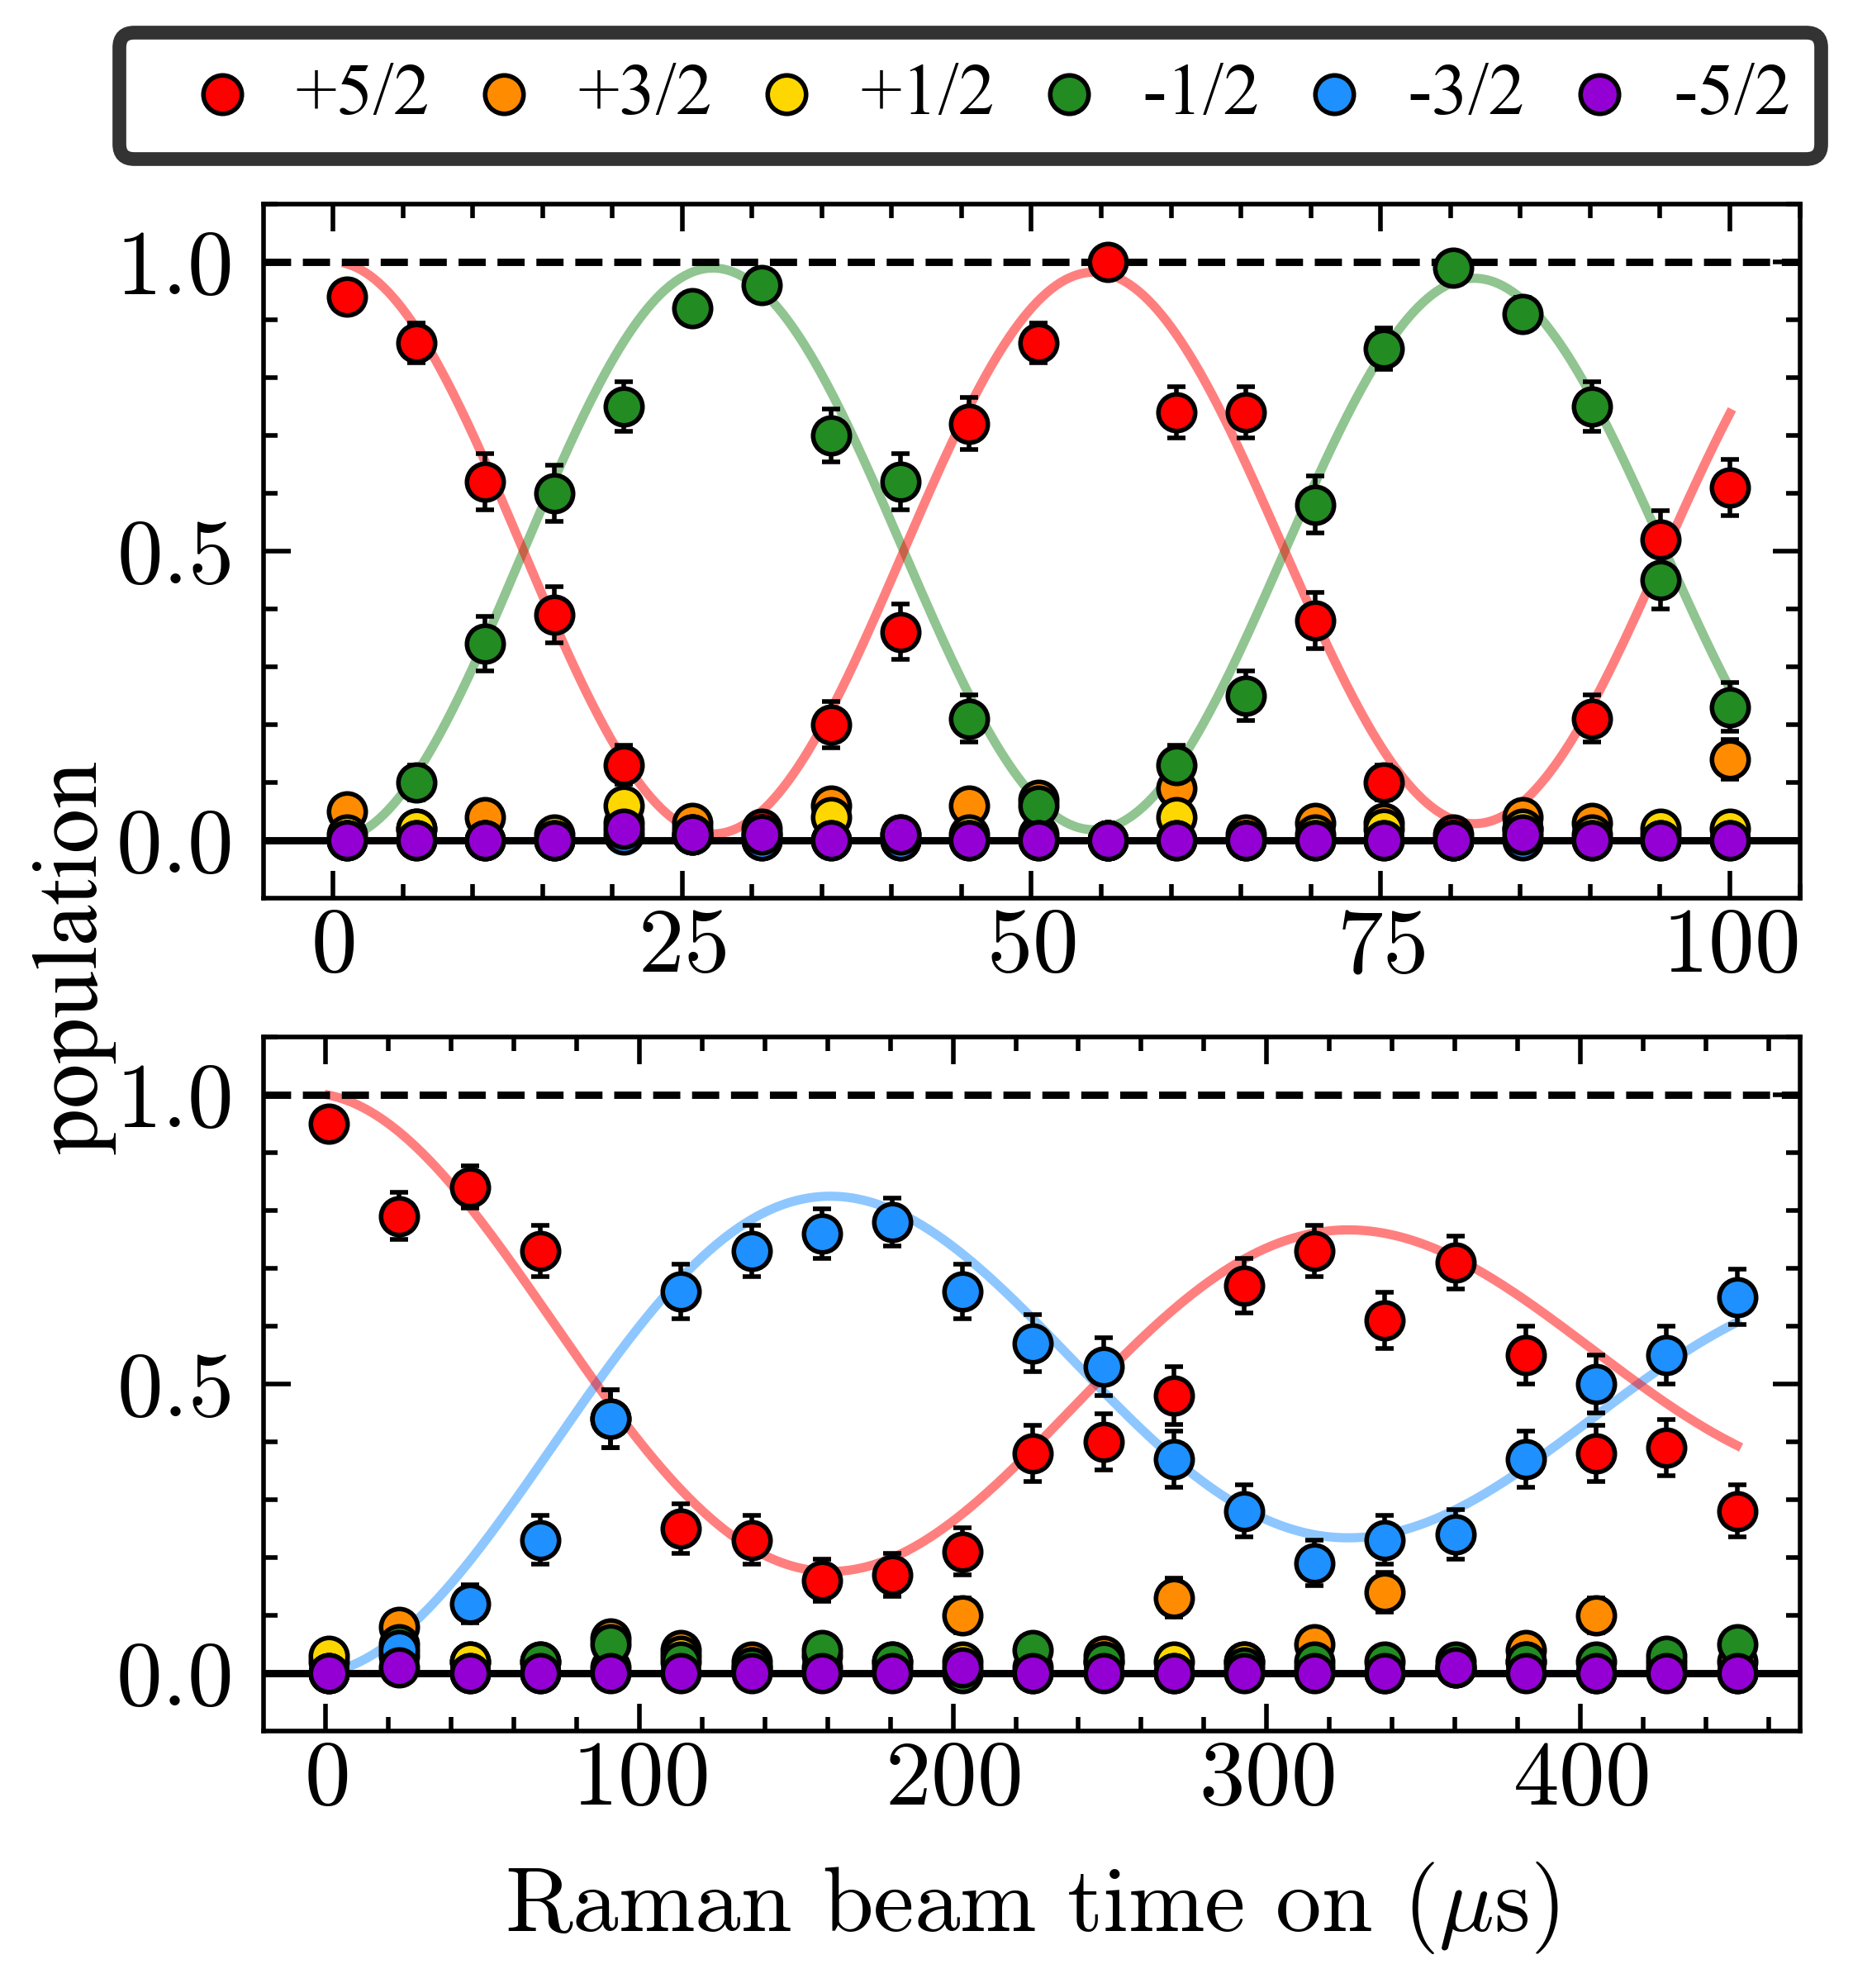

In [6]:
with plt.style.context(['science','no-latex']):
    colors = ['red','darkorange','gold','forestgreen','dodgerblue','darkviolet']
    cs = 1
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(3, 3), dpi = 800)
    plt.rcParams["font.family"] = "Times New Roman"

    ax1.plot(fits4[0]*1e6, fits4[1],linewidth = 1, color = 'forestgreen', alpha = .5)
    ax1.plot(fits4[0]*1e6,1 - fits4[1],linewidth = 1, color = 'red', alpha = .5)


    ax1.errorbar(t*1e6, p52, p52_err,marker = '.', markerfacecolor = colors[0],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)
    ax1.errorbar(t*1e6, p32, p32_err,marker = '.', markerfacecolor = colors[1],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)
    ax1.errorbar(t*1e6, p12, p12_err,marker = '.', markerfacecolor = colors[2],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)
    ax1.errorbar(t*1e6, m12, m12_err,marker = '.', markerfacecolor = colors[3],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)
    ax1.errorbar(t*1e6, m32, m32_err,marker = '.', markerfacecolor = colors[4],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)
    ax1.errorbar(t*1e6, m52, m52_err,marker = '.', markerfacecolor = colors[5],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)


    ax1.scatter(3.5,-1,marker = '.',facecolor = colors[0],
                  edgecolor = 'black',
                  s=70,linewidth = .5, label = '+5/2')
    ax1.scatter(3.5,-1,marker = '.',facecolor = colors[1],
                  edgecolor = 'black',
                  s=70, label = '+3/2',linewidth = .5)
    ax1.scatter(3.5,-1,marker = '.',facecolor = colors[2],
                  edgecolor = 'black',
                  s=70, label = '+1/2',linewidth = .5)
    ax1.scatter(3.5,-1,marker = '.',facecolor = colors[3],
                  edgecolor = 'black',
                  s=70,linewidth = .5, label = '-1/2')
    ax1.scatter(3.5,-1,marker = '.',facecolor = colors[4],
                  edgecolor = 'black',
                  s=70, label = '-3/2',linewidth = .5)
    ax1.scatter(3.5,-1,marker = '.',facecolor = colors[5],
                  edgecolor = 'black',
                  s=70, label = '-5/2',linewidth = .5)
    ax1.axhline(1, color = 'black', linewidth = 0.8, linestyle = '--')
    ax1.axhline(0, color = 'black', linewidth = 0.8)

    #ax1.set_ylabel('population')


    L = ax1.legend(loc = 'upper center',bbox_to_anchor=(0.46, 1.3),
               ncol = 6,handletextpad=0,
               columnspacing=0,frameon = True,fontsize=8)
    # L = ax1.legend(loc = 'upper center',bbox_to_anchor=(0.46, 1.4),
    #            ncol = 1,handletextpad=0,
    #            columnspacing=0,frameon = True)
    legend_box = L.get_frame()  # Get the legend's bounding box
    legend_box.set_edgecolor('black')  # Set legend border color
    legend_box.set_linewidth(1.5)  # Set legend border width

    
    
    
    ax1.set_ylim(-.1,1.1)
    ax1.set_xlim(-5, 105)

    #ax1.xaxis.set_ticks_position('top')

    #ax1.grid(linewidth = .2, color = 'black')
    ax1.tick_params(axis='x', pad=1) 
    plt.subplots_adjust(hspace=.2)

    others6 = [np.mean(p326),np.mean(p126),np.mean(m126),np.mean(m526)]

    # ax2.plot(tfit_6*1e6, yfit_6/(1+np.mean(others6)), color = 'black',linewidth = .5)
    # ax2.plot(tfit_6*1e6, 1- yfit_6/(1+np.mean(others6)) - np.mean(others6), color = 'black',linewidth = .5)
    sum6 = np.sum(np.mean(p326)+np.mean(p126)+np.mean(m126)+np.mean(m526))
    sum6 = 0
    ax2.plot(fits6[0]*1e6, fits6[1]/(1-sum6),linewidth = 1, color = 'dodgerblue', alpha = .5)
    ax2.plot(fits6[0]*1e6, 1-fits6[1]/(1-sum6),linewidth = 1, color = 'red', alpha = .5)

    ax2.errorbar(t6*1e6, p526, p526_err,marker = '.', markerfacecolor = colors[0],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)
    ax2.errorbar(t6*1e6, p326, p326_err,marker = '.', markerfacecolor = colors[1],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)
    ax2.errorbar(t6*1e6, p126, p126_err,marker = '.', markerfacecolor = colors[2],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)
    ax2.errorbar(t6*1e6, m126, m126_err,marker = '.', markerfacecolor = colors[3],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)
    ax2.errorbar(t6*1e6, m326, m326_err,marker = '.', markerfacecolor = colors[4],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)
    ax2.errorbar(t6*1e6, m526, m526_err,marker = '.', markerfacecolor = colors[5],
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=cs, elinewidth = .5)
    ax2.tick_params(axis='x', pad=1) 
    ax2.set_xlabel(r'Raman beam time on ($\mu$s)')
    ax2.set_ylim(-.1,1.1)
    ax2.set_xlim(-20, 470)
    #ax2.grid(linewidth = .2, color = 'black')
    ax2.axhline(1, color = 'black', linewidth = 0.8, linestyle = '--')
    ax2.axhline(0, color = 'black', linewidth = 0.8)
    fig.text(0.03, 0.5, 'population', va='center', ha='center', rotation='vertical', fontsize=10)
    plt.show()